# Detecção de produtos de higiene com YOLOv7

Detector de **12 classes** de produtos de higiene pessoal, treinado com **YOLOv7** (fine-tuning a partir de pesos pré-treinados) em dataset próprio, rotulado em formato YOLO.

**Classes:** álcool em gel, aparelho de barbear, condicionador, pasta de dente, desodorante, escova de dente, hidratante, papel higiênico, perfume, sabonete em barra, sabonete líquido, shampoo.

**Resultados (conjunto de teste, 65 imagens nunca vistas):** mAP@.5 = 0.784 | mAP@.5:.95 = 0.568

> Ambiente: Google Colab com GPU T4 (menu *Ambiente de execução → Alterar tipo → T4 GPU*).

## 1. Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE = '/content/drive/MyDrive/uvv/yolov7-main'   # pasta do YOLOv7 no Drive
%cd {BASE}
!pip install -q seaborn thop

/content/drive/MyDrive/uvv/yolov7-main


**Nota de compatibilidade:** versões novas do PyTorch (≥ 2.6) bloqueiam o carregamento de checkpoints antigos do YOLOv7 (`weights_only=True`).
A correção usada foi adicionar, no topo do `train.py`, uma linha que força `weights_only=False` no `torch.load`. Isso só deve ser feito com arquivos de confiança (aqui, os próprios pesos do projeto).
Basta aplicar **uma vez**; confira com `!head -n 12 train.py`.

In [ ]:
!head -n 12 train.py

import argparse
import torch
try:
    from models.yolo import Model
    torch.serialization.add_safe_globals([Model])
except:
    pass
import builtins
orig_load = torch.load
torch.load = lambda *args, **kwargs: orig_load(*args, **{**kwargs, "weights_only": False})
import logging
import math


## 2. Dataset
Os conjuntos estão em zips no Drive (imagem e label `.txt` na mesma pasta). A pasta `/content/dataset` é temporária, então esta célula precisa rodar sempre que o Colab reiniciar.

In [4]:
import os
!rm -rf /content/dataset
!mkdir -p /content/dataset/treino /content/dataset/validacao /content/dataset/teste
!unzip -q "{BASE}/Treinos (2).zip" -d /content/dataset/treino
!unzip -q "{BASE}/Validação.zip" -d /content/dataset/validacao
!unzip -q "{BASE}/Testes.zip" -d /content/dataset/teste

for s in ['treino', 'validacao', 'teste']:
    imgs = labels = 0
    for r, d, f in os.walk(f'/content/dataset/{s}'):
        imgs += sum(x.lower().endswith(('.jpg', '.jpeg', '.png')) for x in f)
        labels += sum(x.endswith('.txt') for x in f)
    print(f'{s}: {imgs} imagens, {labels} labels')

treino: 470 imagens, 469 labels
validacao: 136 imagens, 136 labels
teste: 65 imagens, 65 labels


**Formato dos labels (YOLO):** um `.txt` por imagem, uma linha por objeto:

```
classe  centro_x  centro_y  largura  altura
2       0.447080  0.450957  0.535315  0.721739
```
Todos os valores de posição e tamanho são **normalizados (0 a 1)** em relação à largura e altura da imagem. A classe é o índice na lista `names` do arquivo yaml (2 = condicionador).

In [ ]:
yaml_content = '''
train: /content/dataset/treino
val: /content/dataset/validacao
test: /content/dataset/teste

nc: 12
names: ['alcool_em_gel','aparelho_de_barbear','condicionador','pasta_de_dente','desodorante','escova_de_dente','hidratante','papel_higienico','perfume','sabonete_barra','sabonete_liquido','shampoo']
'''
open(f'{BASE}/data/custom.yaml', 'w').write(yaml_content.strip())
print('custom.yaml criado')

custom.yaml criado


## 3. Treinamento
Fine-tuning a partir do `yolov7.pt` (100 épocas, batch 16, 640x640, hiperparâmetros `hyp.scratch.p5.yaml`).

Comparação feita no projeto:

| Treino | Pesos iniciais | mAP@.5 (validação) |
|---|---|---|
| Do zero | nenhum | 0.16 |
| **Fine-tuning** | `yolov7.pt` | **0.76** |

O treino com pesos pré-treinados (transfer learning) foi muito superior, pois o dataset é pequeno (470 imagens de treino).

In [ ]:
import os
os.environ['WANDB_MODE'] = 'disabled'
# Treino novo (se for retomar um treino interrompido, use a célula seguinte)
# !python train.py --workers 2 --device 0 --batch-size 16 --epochs 100 --data data/custom.yaml --img 640 --cfg cfg/training/yolov7.yaml --weights yolov7.pt --name detector_produtos_yolov7 --hyp data/hyp.scratch.p5.yaml

In [ ]:
# Retomar treino interrompido (Colab caiu)
# !python train.py --resume runs/train/detector_produtos_yolov74/weights/last.pt

## 4. Avaliação no conjunto de teste
O `--task test` avalia as imagens de teste (nunca vistas no treino nem na validação). Apagamos o cache antigo para evitar o erro de `weights_only`.

In [ ]:
!rm -f /content/dataset/teste/Testes.cache
!python test.py --data data/custom.yaml --img 640 --batch 16 --task test --device 0 \
  --weights modelo_final_produtos_higiene.pt --name teste_final

Namespace(weights=['modelo_final_produtos_higiene.pt'], data='data/custom.yaml', batch_size=16, img_size=640, conf_thres=0.001, iou_thres=0.65, task='test', device='0', single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project='runs/test', name='teste_final', exist_ok=False, no_trace=False, v5_metric=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.11.0+cu130 CUDA:0 (Tesla T4, 14912.6875MB)

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse
/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Model Summary: 314 layers, 36541106 parameters, 6194944 gradients, 103.3 GFLOPS
 Convert model to Traced-model... 
 tra

### Resultados no teste (65 imagens, 154 objetos)

| | Época 58 | **Final (época 99)** |
|---|---|---|
| mAP@.5 | 0.663 | **0.784** |
| mAP@.5:.95 | 0.465 | **0.568** |
| Recall | 0.589 | **0.838** |
| Precisão | 0.646 | 0.609 |

**Pontos fracos:** shampoo (mAP@.5 = 0.36), desodorante (precisão baixa, 0.42) e condicionador (precisão 0.31). Frascos parecidos (shampoo, condicionador, hidratante) são confundidos entre si. O teste tem poucos exemplos por classe (4 a 14, exceto desodorante com 59), então as notas por classe variam bastante.

## 5. Gráficos de análise
Curva F1 (usada para escolher o limiar de confiança ótimo, **0.30**), matriz de confusão e curva PR.

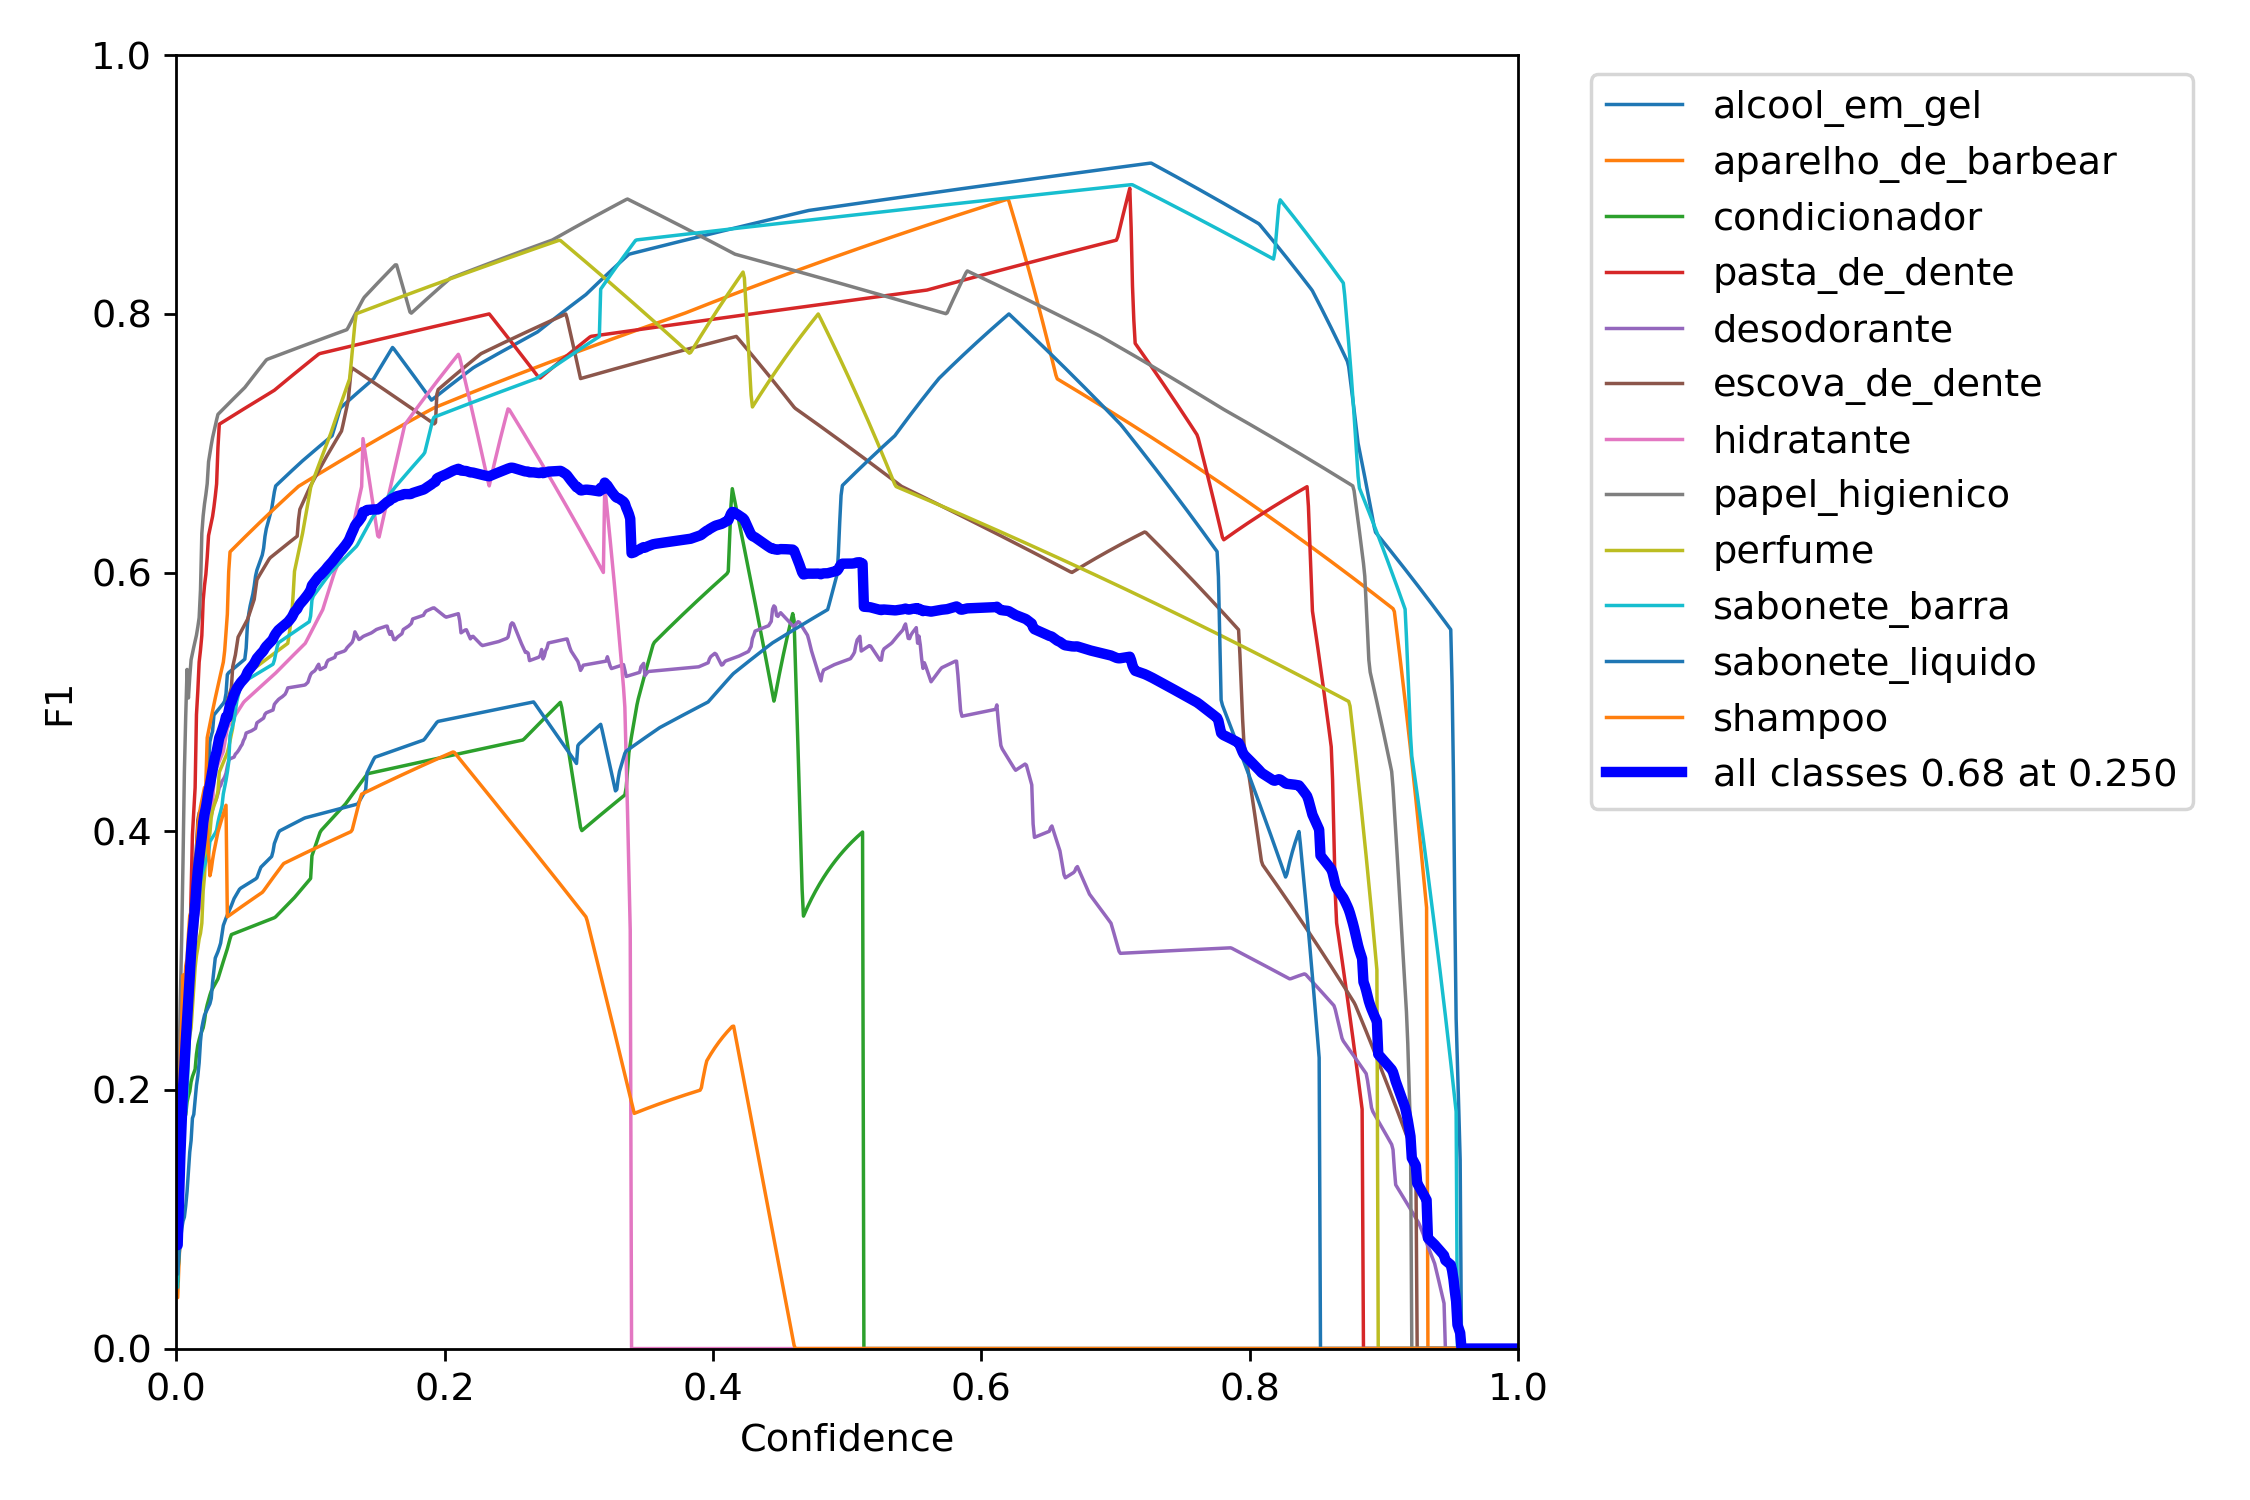

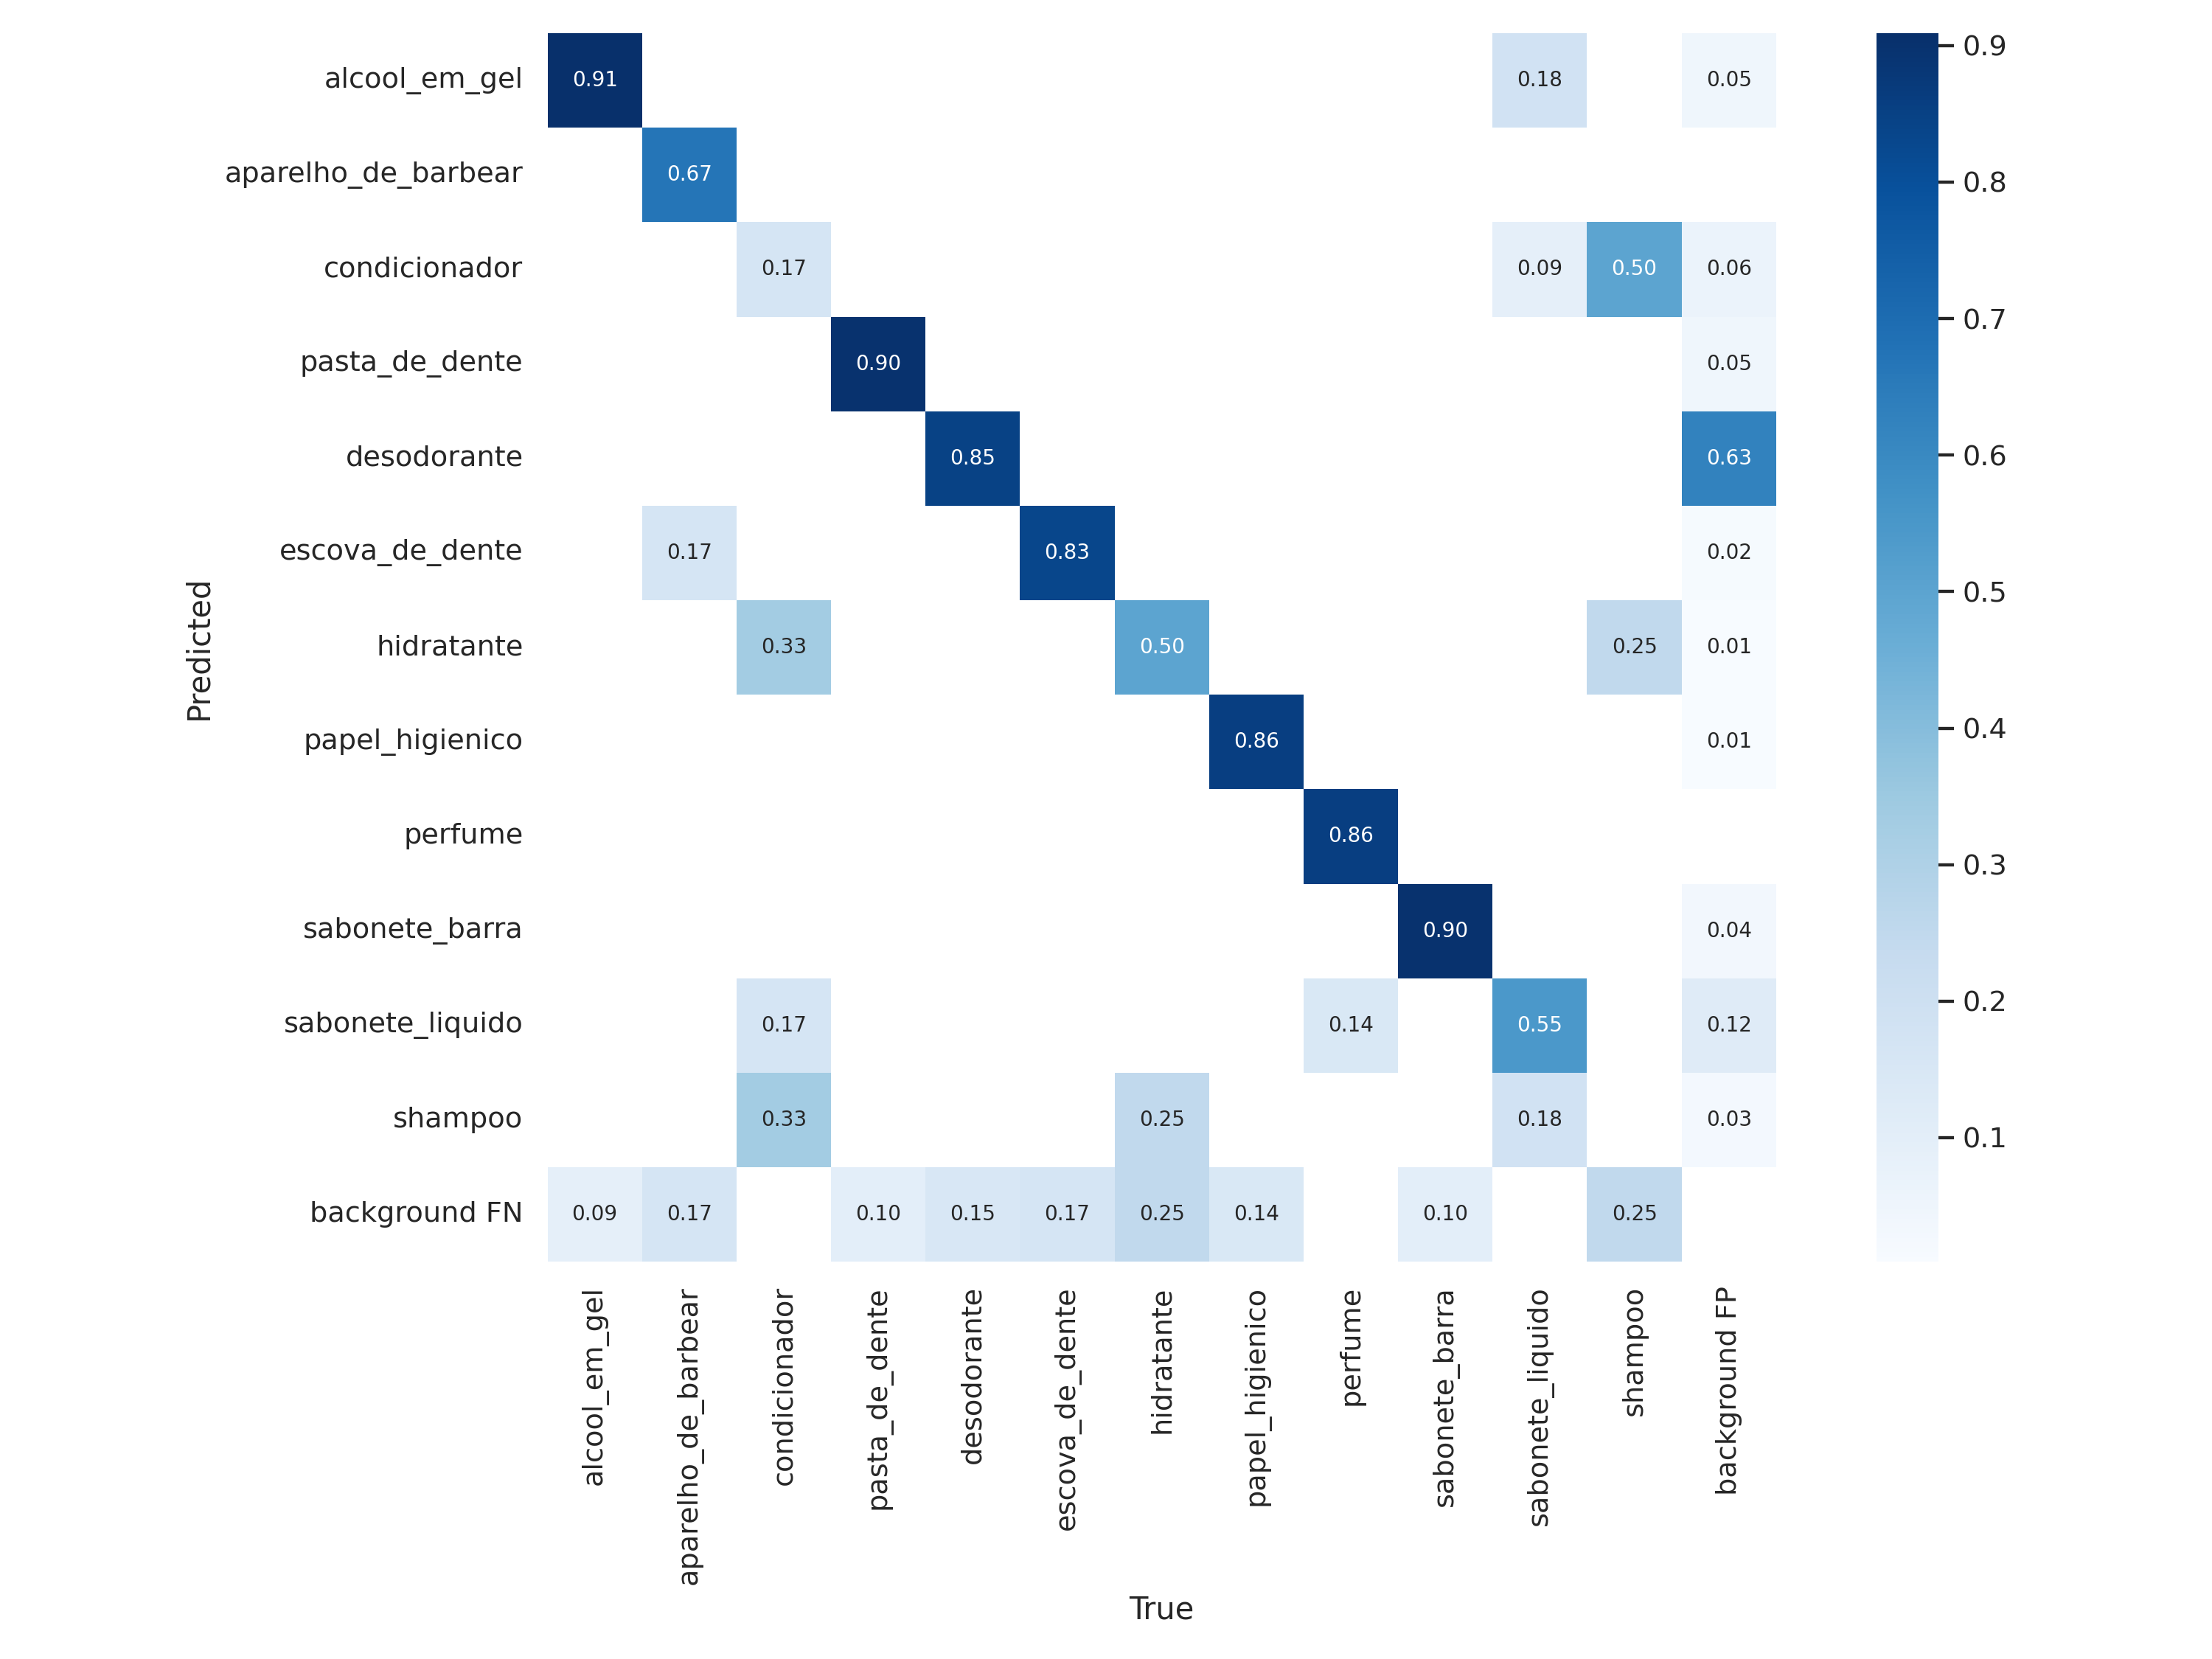

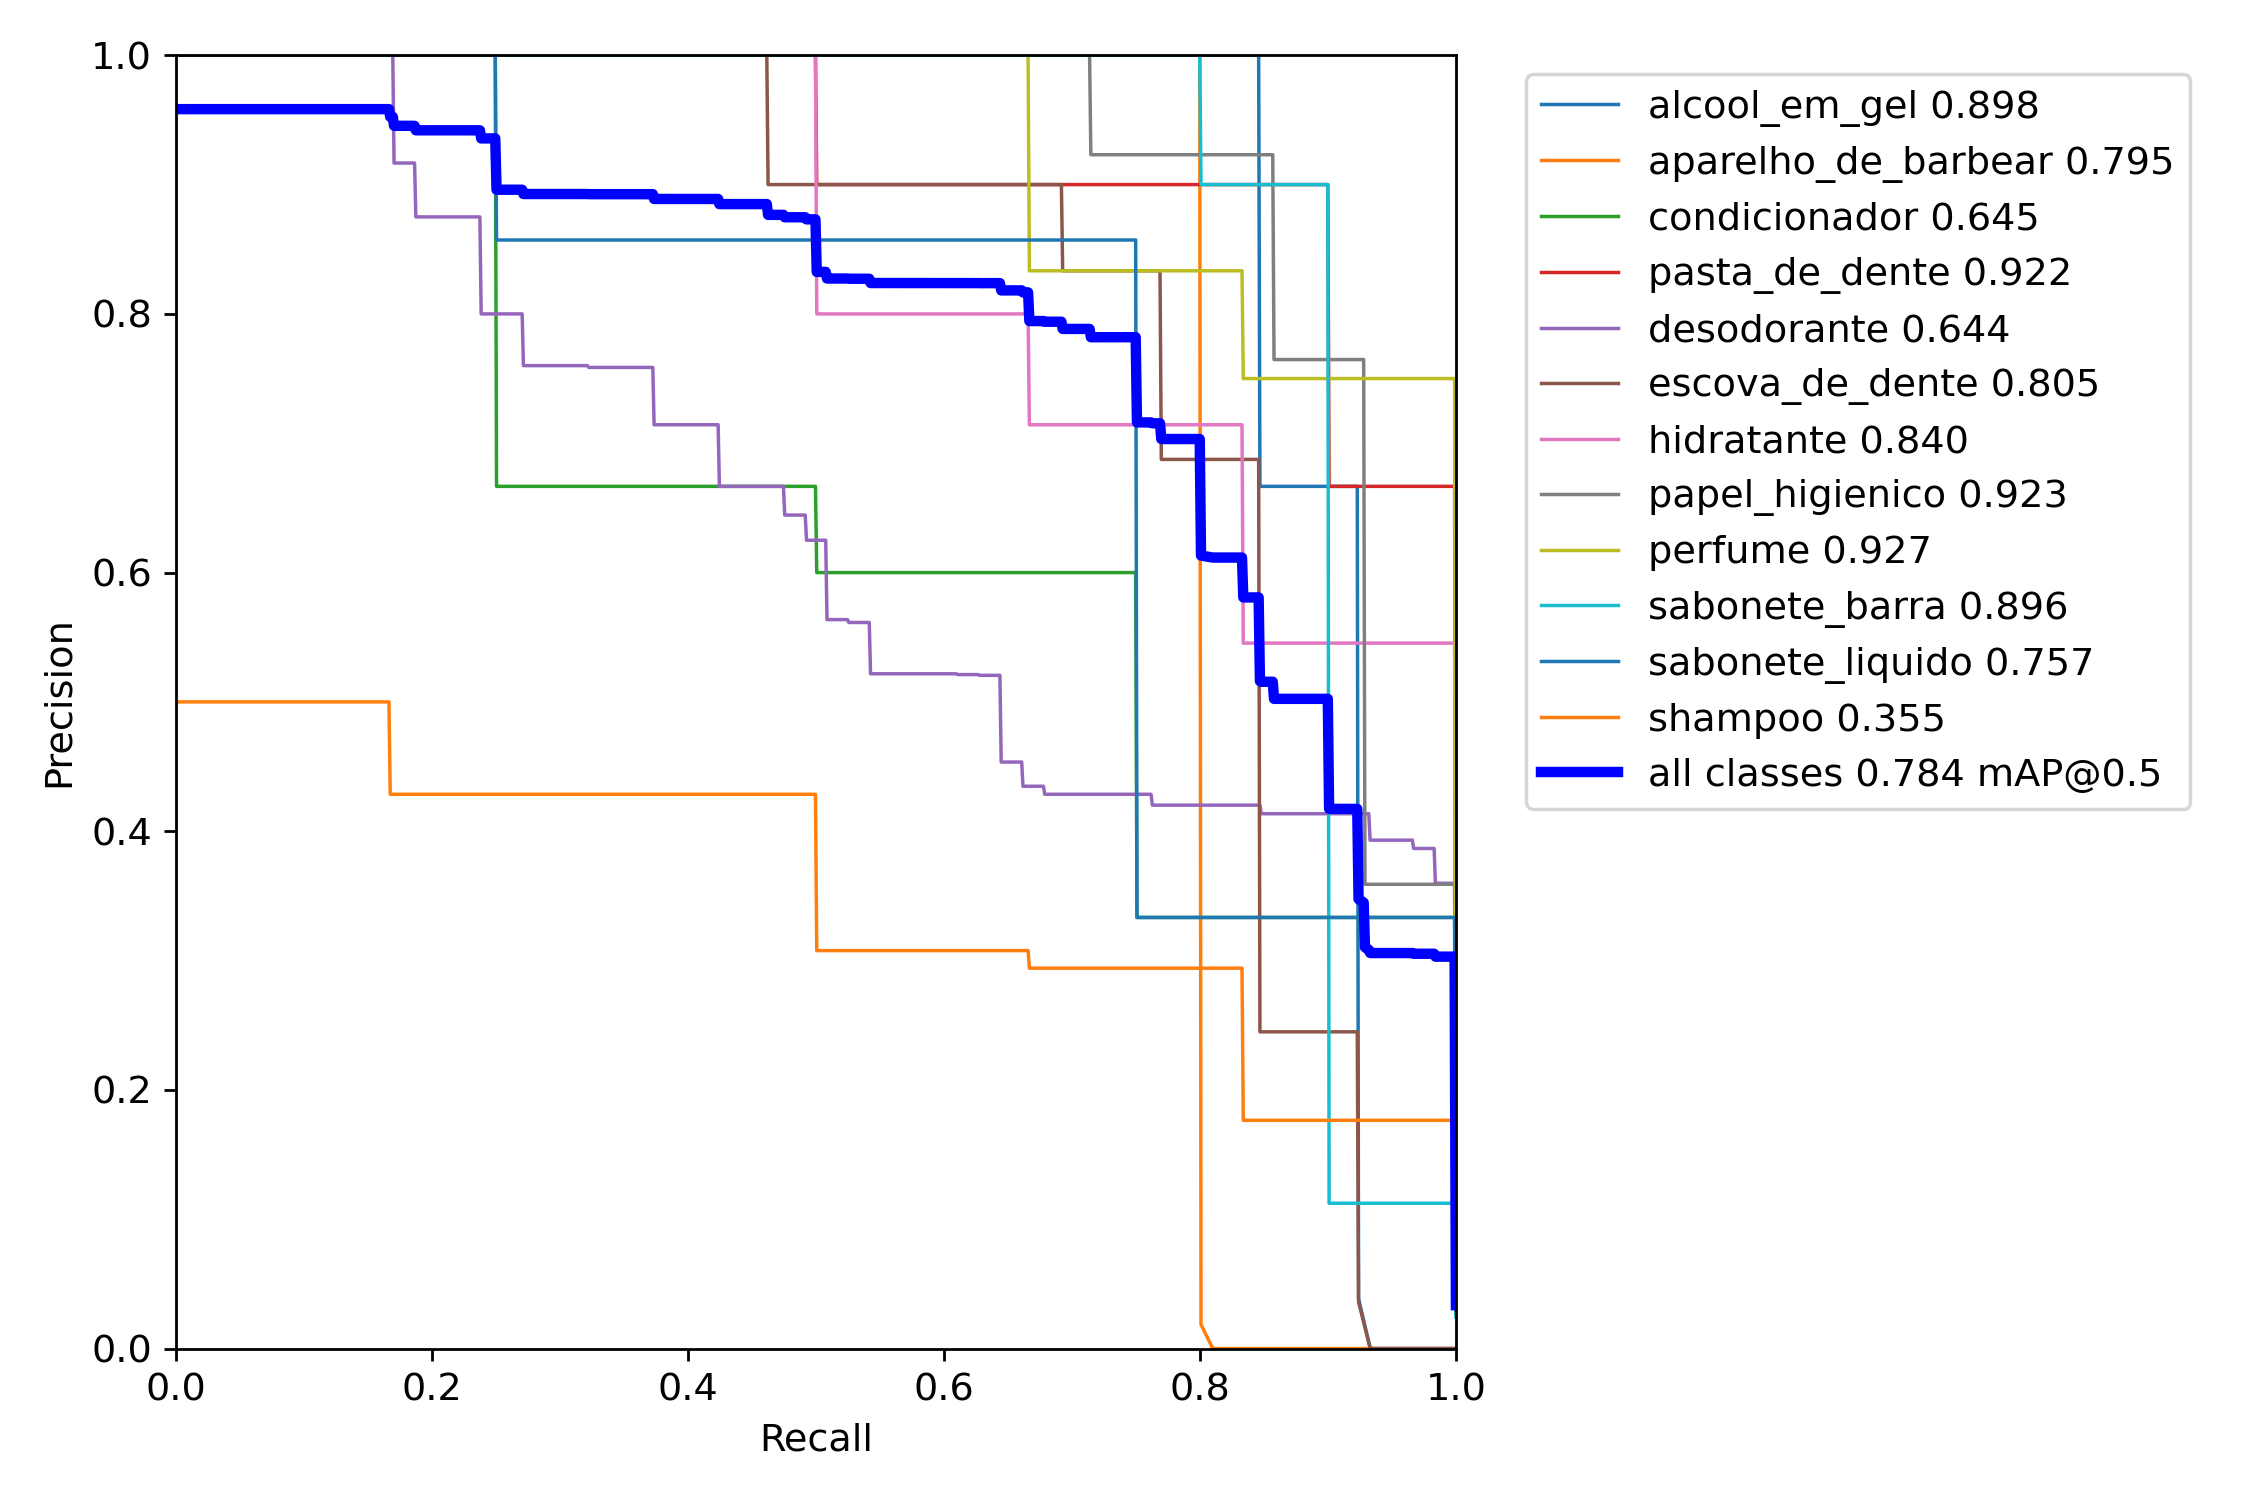

In [ ]:
from IPython.display import Image, display
p = 'runs/test/teste_final/'
for f in ['F1_curve.png', 'confusion_matrix.png', 'PR_curve.png']:
    display(Image(p + f, width=650))

## 6. Inferência em novas imagens
Limiar de confiança **0.30**, escolhido pelo pico da curva F1.

In [ ]:
!python detect.py --source /content/dataset/teste/Testes --weights modelo_final_produtos_higiene.pt \
  --conf 0.30 --iou 0.45 --device 0 --name resultados_finais

Namespace(weights=['modelo_final_produtos_higiene.pt'], source='/content/dataset/teste/Testes', img_size=640, conf_thres=0.3, iou_thres=0.45, device='0', view_img=False, save_txt=False, save_conf=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='runs/detect', name='resultados_finais', exist_ok=False, no_trace=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.11.0+cu130 CUDA:0 (Tesla T4, 14912.6875MB)

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse
/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Model Summary: 314 layers, 36541106 parameters, 6194944 gradients, 103.3 GFLOPS
 Convert model to Traced-model... 
 traced_script_modu

In [ ]:
import glob
from IPython.display import Image, display
for f in sorted(glob.glob('runs/detect/resultados_finais*/*.*'))[:6]:
    display(Image(f, width=500))